### Data Extraction from PDF

##### Installing the required libraries:

In [12]:
!pip install pymupdf4llm docling opendataloader_pdf marker-pdf unstructured pymupdf4llm pandas matplotlib seaborn scikit-learn pytesseract pillow

In [1]:
# Standard imports used throughout the project
import os, sys
import time
import json
import warnings
import pandas as pd
import seaborn as sns
from datetime import datetime
from pathlib import Path
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

warnings.filterwarnings('ignore')

In [2]:
# Load API keys from .env
load_dotenv()  # reads .env in the project root

# Project root (works whether you open the notebook from the repo root or not)
ROOT = Path().resolve()
if not (ROOT / 'adapters').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

CORPUS_DIR      = ROOT / 'corpus'
GROUND_TRUTH_DIR = ROOT / 'ground_truth'
OUTPUT_DIR      = ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

print(f'Root: {ROOT}')
print(f'PDFs found: {list(CORPUS_DIR.glob("*.pdf"))}')

Root: /workspaces/PDF_Data_Extraction
PDFs found: [PosixPath('/workspaces/PDF_Data_Extraction/corpus/2_perfect-pitch-deck.pdf'), PosixPath('/workspaces/PDF_Data_Extraction/corpus/3_NVCA-Model-Voting-Agreement.pdf'), PosixPath('/workspaces/PDF_Data_Extraction/corpus/5_2025-Annual-Integrated-Report.pdf'), PosixPath('/workspaces/PDF_Data_Extraction/corpus/4_SA-war-scanned.pdf'), PosixPath('/workspaces/PDF_Data_Extraction/corpus/1_Rapport-financier-semestriel-AFD-2025.pdf')]


In [3]:
# Corpus overview: page count, file size, rough text vs image ratio
import fitz  # PyMuPDF

pdf_files = sorted(CORPUS_DIR.glob('*.pdf'))

if not pdf_files:
    print('No PDFs found in corpus/. Add your 5 PDFs first.')
else:
    print(f'{'PDF':<35} {'Pages':>6} {'Size MB':>8} {'Text chars':>12} {'Images':>8} {'Type guess':>12}')
    print('-' * 85)
    
    for pdf_path in pdf_files:
        doc = fitz.open(str(pdf_path))
        n_pages = doc.page_count
        size_mb = pdf_path.stat().st_size / 1e6
        total_chars, total_images = 0, 0
        for page in doc:
            total_chars  += len(page.get_text())
            total_images += len(page.get_images())
        avg_chars = total_chars / n_pages if n_pages else 0
        
        if avg_chars < 1000 and total_images > 5:
            pdf_type = 'Image-heavy'
        elif avg_chars > 5000:
            pdf_type = 'Text-heavy'
        else:
            pdf_type = 'Mixed'
        print(f'{pdf_path.name:<35} {n_pages:>6} {size_mb:>8.1f} {total_chars:>12,} {total_images:>8} {pdf_type:>12}')
        doc.close()

PDF                                  Pages  Size MB   Text chars   Images   Type guess
-------------------------------------------------------------------------------------
1_Rapport-financier-semestriel-AFD-2025.pdf     53      0.7      150,986        2        Mixed
2_perfect-pitch-deck.pdf                16      3.8        1,000       15  Image-heavy
3_NVCA-Model-Voting-Agreement.pdf       23      0.3       83,336        0        Mixed
4_SA-war-scanned.pdf                    15      0.6       18,285       30        Mixed
5_2025-Annual-Integrated-Report.pdf     36      7.9       66,635       76        Mixed


##### Ground Truth:

In [ ]:
# Generate a starting-point ground truth for one page 
GT_PDF  = pdf_files[0]   
GT_PAGE = 4              

doc  = fitz.open(str(GT_PDF))
page = doc[GT_PAGE - 1]

# extract text blocks from the page
blocks = page.get_text('blocks')

# Sort by vertical position then horizontal 
blocks_sorted = sorted(blocks, key=lambda b: (round(b[1]/20)*20, b[0]))

text_parts = []
for block in blocks_sorted:
    text = block[4].strip()

    if text:
        text_parts.append(text)

draft_text    = '\n\n'.join(b[4].strip() for b in blocks_sorted if b[4].strip())

doc.close()

In [24]:
# Print it for review
print(f'=== DRAFT ground truth: {GT_PDF.name}, page {GT_PAGE} ===')
print(draft_text[:5000])  # first 5000 chars
if len(draft_text) > 5000:
    print(f'... [{len(draft_text) - 5000} more chars — open the file to see all]')

# Auto-save (then manually edit the file) 
gt_dir = GROUND_TRUTH_DIR / GT_PDF.stem
gt_dir.mkdir(parents=True, exist_ok=True)
save_path = gt_dir / f'page_{GT_PAGE}.md'
save_path.write_text(draft_text, encoding='utf-8')
print(f'\nSaved to {save_path}')

=== DRAFT ground truth: 5_2025-Annual-Integrated-Report.pdf, page 13 ===
OUR STAKEHOLDERS
OUR MATERIALITY MATRIX

Since 2015, Saint-Gobain has regularly carried out 
“double materiality” assessments to identify and 
prioritize the impacts that are most significant for both 
the company and its stakeholders, and those with 
a major financial impact. The update of the double 
materiality analysis carried out in 2024 is based on 
the ESRS (European Sustainability Reporting Standards). 
This change in methodology has not led to any major 
changes in the list of material challenges for 
Saint-Gobain. The matrix is a representation made 
based on the results of the double materiality analysis.

Materiality challenges have been classified according 
to the contributions of the CSR roadmap. Sustainability 
issues were identified based on:

■Information and knowledge gained from previous 
financial years;

■Sector-specific reference frameworks specifying the 
priority issues linked to construct

In [11]:
import fitz
import csv
from pathlib import Path

GT_PDF     = pdf_files[0]
TABLE_PAGE = 15

# Open PDF
with fitz.open(str(GT_PDF)) as doc:

    # PyMuPDF uses 0-based indexing
    page = doc[TABLE_PAGE - 1]

    # Print all text blocks with coordinates
    print(f'Text blocks on page {TABLE_PAGE}:\n')

    blocks = sorted(
        page.get_text("blocks"),
        key=lambda b: (b[1], b[0])   # sort top-to-bottom, left-to-right
    )

    for block in blocks:

        # Unpack block tuple
        x0, y0, x1, y1, text, block_no, block_type = block

        text = text.strip()

        if text:
            print(f'y={y0:6.0f}  x={x0:6.0f}  "{text[:80]}"')

print('\n--- Building ground-truth table ---')

# Manually reconstructed table from the PDF
correct_table = [

    # Header
    [
        'Assets',
        '30 Jun 25',
        '31 Dec 24',
        'Change'
    ],

    # Rows
    ['Cash, due from central banks',
     '1,529,779',
     '863,504',
     '666,274'],

    ['Financial assets at fair value through profit or loss',
     '3,868,930',
     '4,739,783',
     '(870,853)'],

    ['Hedging derivatives',
     '2,586,028',
     '3,341,422',
     '(755,394)'],

    ['Financial assets at fair value through other comprehensive income',
     '3,434,606',
     '2,273,869',
     '1,160,737'],

    ['Debt securities at amortised cost',
     '4,031,971',
     '3,148,432',
     '883,539'],

    ['Financial assets at amortised cost',
     '53,009,695',
     '53,772,227',
     '(762,531)'],

    ['Loans and receivables due from credit institutions and equivalent at amortised cost',
     '12,637,006',
     '13,303,340',
     '(666,334)'],

    ['On-demand',
     '932,054',
     '1,213,880',
     '(281,826)'],

    ['At maturity',
     '11,704,952',
     '12,089,460',
     '(384,508)'],

    ['Loans and receivables due from customers at amortised cost',
     '40,372,689',
     '40,468,886',
     '(96,198)'],

    ['Other loans to customers',
     '40,372,689',
     '40,468,886',
     '(96,198)'],

    ['Of which calibration of the reserve account',
     '(1,047,780)',
     '(930,187)',
     '(117,592)'],

    ['Revaluation differences on interest rate-hedged portfolio',
     '14,045',
     '45,209',
     '(31,164)'],

    ['Current tax assets',
     '8,398',
     '5,966',
     '2,432'],

    ['Deferred tax assets',
     '27,419',
     '27,513',
     '(93)'],

    ['Accruals and other miscellaneous assets',
     '3,466,979',
     '2,907,962',
     '559,017'],

    ['Accruals',
     '96,148',
     '53,516',
     '42,632'],

    ['Other assets',
     '3,370,831',
     '2,854,445',
     '516,386'],

    ['Equity stakes in companies accounted for by the equity method',
     '158,014',
     '160,320',
     '(2,305)'],

    ['Fixed assets property, plant and equipment',
     '902,952',
     '858,161',
     '44,791'],

    ['Intangible assets',
     '190,124',
     '182,597',
     '7,527'],

    ['TOTAL ASSETS',
     '73,228,942',
     '72,326,964',
     '901,978']
]

# Create output directory
gt_dir = GROUND_TRUTH_DIR / GT_PDF.stem
gt_dir.mkdir(parents=True, exist_ok=True)

# Save CSV
csv_path = gt_dir / 'balance_sheet_assets.csv'

with open(csv_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerows(correct_table)

print(f'\nSaved ground truth table to:\n{csv_path}')

Text blocks on page 15:

y=    23  x=    57  "AFD – 2025 half-year financial report 
15"
y=    61  x=    71  "Balance sheet at 30 June 2025"
y=    96  x=    73  "Assets"
y=   113  x=    73  "In thousands of euros
Notes
30 Jun 25
31 Dec 24
Change"
y=   127  x=    73  "Cash, due from central banks
1,529,779
863,504
666,274"
y=   139  x=    73  "Financial assets at fair value through profit or loss
1
3,868,930
4,739,783
(870"
y=   151  x=    73  "Hedging derivatives
2
2,586,028
3,341,422
(755,394)"
y=   163  x=    73  "Financial assets at fair value through other comprehensive income
3
3,434,606
2,"
y=   175  x=    73  "Debt securities at amortised cost
5
4,031,971
3,148,432
883,539"
y=   187  x=    73  "Financial assets at amortised cost
53,009,695
53,772,227
(762,531)"
y=   199  x=    73  "Loans and receivables due from credit institutions and equivalent at 
amortised "
y=   222  x=    80  "On-demand
932,054
1,213,880
(281,826)"
y=   234  x=    80  "At maturity
11,704,952
12,089,460
(38

##### Ground Truth for presentations

<class 'PIL.PngImagePlugin.PngImageFile'>


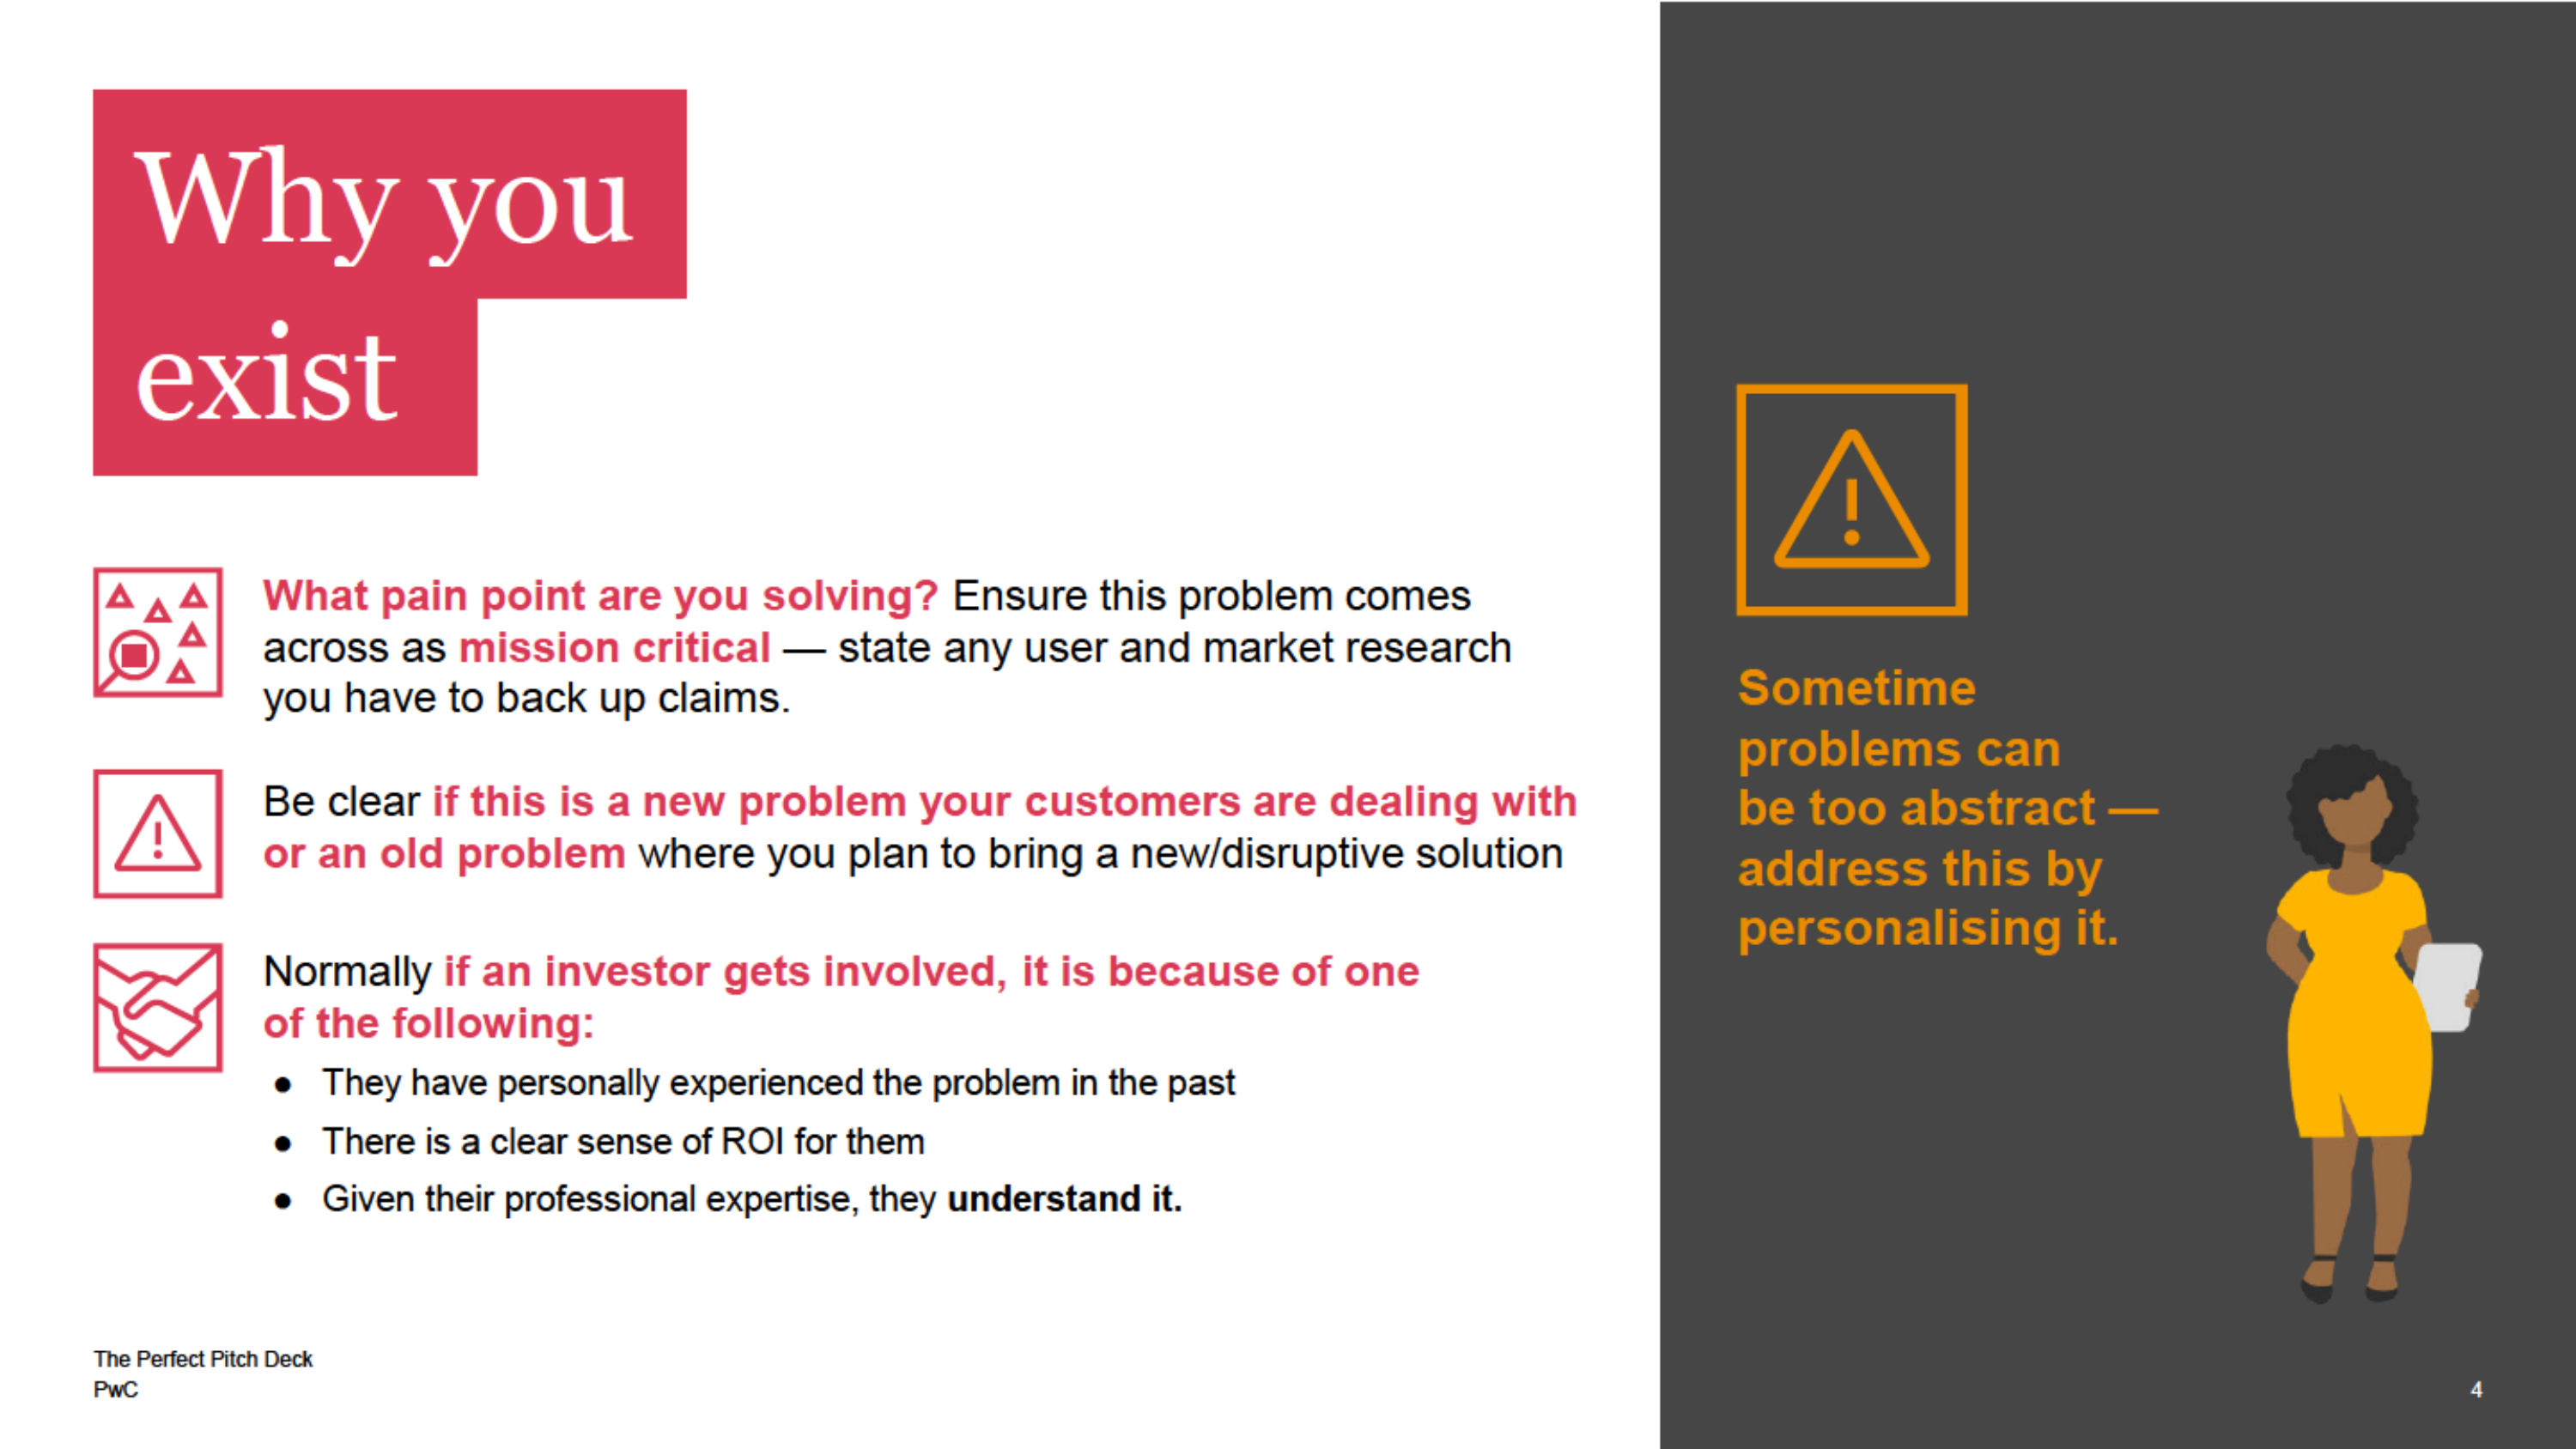

In [15]:
import fitz
import pytesseract
from pytesseract import Output
from PIL import Image
import io

GT_PDF  = pdf_files[1]
GT_PAGE = 4

doc  = fitz.open(str(GT_PDF))
page = doc[GT_PAGE - 1]

# Consider a page as an image
pix = page.get_pixmap(dpi=300)
img = Image.open(io.BytesIO(pix.tobytes("png")))

print(type(img))
img.show()

In [16]:
# 2. OCR extraction WITH positions
ocr_data = pytesseract.image_to_data( img, output_type=pytesseract.Output.DICT)

doc.close()

TesseractNotFoundError: C:\Program Files\Tesseract-OCR\tesseract.exe is not installed or it's not in your PATH. See README file for more information.

In [11]:
# 3. Convert OCR words → "block-like" tuples (x, y, text)
blocks = []

for i in range(len(ocr_data["text"])):
    text = ocr_data["text"][i].strip()

    if text:
        x = ocr_data["left"][i]
        y = ocr_data["top"][i]

        # mimic PyMuPDF block structure
        blocks.append((x, y, x, y, text))

# 4. Same sorting logic as your original code
blocks_sorted = sorted(
    blocks,
    key=lambda b: (round(b[1] / 20) * 20, b[0])
)

# 5. Same draft text construction logic
draft_text = "\n\n".join(
    b[4].strip() for b in blocks_sorted if b[4].strip()
)

print(draft_text)

NameError: name 'ocr_data' is not defined

## PDF Extraction

**Goal:** Extract text, tables, images, and metadata from PDF files.

1. PyMuPDF

In [18]:
import fitz  # PyMuPDF

start = time.time()

doc = fitz.open('dataset/invoice_10986.pdf')

all_text = []
for page_num, page in enumerate(doc):
    text = page.get_text()  # Plain text extraction
    all_text.append(text)
    if page_num < 2:  # Print first 2 pages only
        print(f"\n── PAGE {page_num + 1} ──")
        print(text[:500] + ("..." if len(text) > 500 else ""))

elapsed = time.time() - start
speed = len(all_text) / elapsed
print(f"\nExtracted text from {len(all_text)} pages in {elapsed:.2f} seconds ({speed:.2f} pages/second)")


── PAGE 1 ──
Invoice
Order ID: 10986
Customer ID: OCEAN
Order Date: 2018-03-30
Customer Details:
Contact Name:
Yvonne Moncada
Address:
Ing. Gustavo Moncada 8585 Piso 20-A
City:
Buenos Aires
Postal Code:
1010
Country:
Argentina
Phone:
(1) 135-5333
Fax:
(1) 135-5535
Product Details:
Product ID
Product Name
Quantity
Unit Price
11
Queso Cabrales
30
21.0
20
Sir Rodney's Marmalade
15
81.0
76
Lakkalikööri
10
18.0
77
Original Frankfurter grüne Soße
15
13.0
 
 
TotalPrice
2220.0
Page 1


Extracted text from 1 pages in 0.02 seconds (49.60 pages/second)


2. PDF Plumber

In [ ]:
import pdfplumber

start = time.time()

# Extracting text using pdfplumber
doc = fitz.open('dataset/invoice_10986.pdf')

all_text = []
for page_num, page in enumerate(doc):
    with pdfplumber.open('dataset/invoice_10986.pdf') as pdf:
        pdf_page = pdf.pages[page_num]
        text = pdf_page.extract_text()
        all_text.append(text)
        if page_num < 2:  # Print first 2 pages only
            print(f"\n── PAGE {page_num + 1} ──")
            print(text[:500] + ("..." if len(text) > 500 else ""))

elapsed = time.time() - start
speed = len(all_text) / elapsed
print(f"\nExtracted text from {len(all_text)} pages in {elapsed:.2f} seconds ({speed:.2f} pages/second)")


── PAGE 1 ──
Invoice
Order ID: 10986
Customer ID: OCEAN
Order Date: 2018-03-30
Customer Details:
Contact Name: Yvonne Moncada
Address: Ing. Gustavo Moncada 8585 Piso 20-A
City: Buenos Aires
Postal Code: 1010
Country: Argentina
Phone: (1) 135-5333
Fax: (1) 135-5535
Product Details:
Product ID Product Name Quantity Unit Price
11 Queso Cabrales 30 21.0
20 Sir Rodney's Marmalade 15 81.0
76 Lakkalikööri 10 18.0
77 Original Frankfurter grüne Soße 15 13.0
TotalPrice 2220.0
Page 1

Extracted text from 1 pages in 0.11 seconds (9.19 pages/second)
